# Demo Notebook

In [57]:
using ComputationalMechanics
using Graphs

## Core types
Epsilon machines are represented by the `EpsilonMachine` type, which contains a set of causal states and transitions between them. Causal states are represented by the `CausalState` type, which contains a set of outgoing transitions to other causal states.

In [58]:
# probability are stored with a wrapper struct such that p ∈ [0, 1]
p = 0.4
t1 = Transition(0, p, "A")
t2 = Transition(1, 1-p, "B")
t3 = Transition(0, 1.0, "A")
println.([t1, t2, t3]);

0|P(0.4) -> A
1|P(0.6) -> B
0|P(1.0) -> A


In [59]:
c1 = CausalState("A", [t1, t2])
c2 = CausalState("B", [t3])
println.([c1, c2]);

# outgoing transitions are sampled with probabilities as weights
next = sample_next_transition(c1)
println("Sampled next step: $next")

# distribution from a single causal state 
emission_distribution(c1)

State A: 
  0|P(0.4) -> A
  1|P(0.6) -> B
State B: 
  0|P(1.0) -> A
Sampled next step: 1|P(0.6) -> B


DataStructures.DefaultOrderedDict{Int64, Probability, Probability} with 2 entries:
  0 => P(0.4)
  1 => P(0.6)

In [60]:
startstate = "A"
em = EpsilonMachine([c1, c2], startstate)

EpsilonMachine{Int64}
  alphabet: [0, 1]
  states: 2
  transitions: 3

In [61]:
# Epsilon machines can emit 'symbols' of any type
t1 = Transition('H', 0.5, "S1")
t2 = Transition('T', 0.5, "S2")
t3 = Transition('H', 1.0, "S1")
c1 = CausalState("S1", [t1, t2])
c2 = CausalState("S2", [t3])
EpsilonMachine([c1, c2], "S1")

EpsilonMachine{Char}
  alphabet: ['H', 'T']
  states: 2
  transitions: 3

In [62]:
# Epsilon machines store as a graph internally
display(Graphs.adjacency_matrix(em.graph))

# transition matrix of the ε-machine
display(transition_matrix(em))

# eigenvalues of the transition matrix
stationary_distribution(em)

2×2 SparseArrays.SparseMatrixCSC{Int64, Int64} with 3 stored entries:
 1  1
 1  ⋅

2×2 Matrix{Float64}:
 0.4  0.6
 1.0  0.0

DataStructures.DefaultOrderedDict{String, Probability, Probability} with 2 entries:
  "A" => P(0.62)
  "B" => P(0.37)

In [63]:
@show topological_complexity(em)

@show statistical_complexity(em)

@show entropy_rate(em)

topological_complexity(em) = 1.0
statistical_complexity(em) = 0.9544340029249649
entropy_rate(em) = 0.6068441215341679


0.6068441215341679

## Simulating and Plotting

In [64]:
@show simulate(String, em, 10)
@show simulate(Vector, em, 10)

# Epsilon machines are iterable, so we can use them with any iterable interface
for (i, symbol) in enumerate(em)
    println("Step $i: $symbol")
    i >= 5 && break
end

simulate(String, em, 10) = "1001001001"
simulate(Vector, em, 10) = [1, 0, 1, 0, 1, 0, 0, 1, 0, 0]
Step 1: 1
Step 2: 0
Step 3: 1
Step 4: 0
Step 5: 0


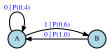

In [65]:
plot_machine(em)  # I'm not sure why the output is so small

In [66]:
# create a dot string representation of the ε-machine
dot_str = mktemp() do file, io
    to_dot_file(em, file)
    read(file, String)
end
println(dot_str)

digraph G {
  graph [rankdir="LR"];
  node [color="black",fontsize="7.0",width="0.25",height="0.25",fixedsize="true",shape="circle",style="filled",fillcolor="lightblue"];
  edge [arrowsize="0.5",arrowtype="normal",fontsize="7.0",color="black",fontcolor="blue"];
  A [label="A"];
  B [label="B"];
  A -> A [weight="0.4",label="0 | P(0.4)"];
  A -> B [weight="0.6",label="1 | P(0.6)"];
  B -> A [weight="1.0",label="0 | P(1.0)"];
}



## Synthetic Processes

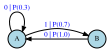

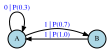

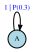

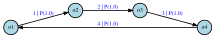

In [67]:
p = 0.3
golden_mean_process(p) |> plot_machine
even_process(p) |> plot_machine
biased_coin_process(p) |> plot_machine
periodic_process(1:4) |> plot_machine

EpsilonMachine{Char}
  alphabet: ['A', 'B']
  states: 7
  transitions: 14


7×7 Matrix{Float64}:
 0.1875  0.8125  0.0     0.0     0.0     0.0     0.0
 0.0     0.0     0.1875  0.8125  0.0     0.0     0.0
 0.0     0.0     0.0     0.0     0.5625  0.4375  0.0
 0.0     0.0     0.9375  0.0625  0.0     0.0     0.0
 0.5625  0.0     0.0     0.0     0.0     0.0     0.4375
 0.0     0.0     0.25    0.75    0.0     0.0     0.0
 0.0     0.0     0.75    0.25    0.0     0.0     0.0

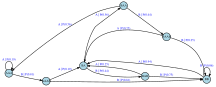

In [68]:
# based on example in Feldman, J., & Hanna, J. F. (1966).
fhp = feldman_hanna_process()

println(fhp)

display(transition_matrix(fhp))

plot_machine(fhp)

## Inference

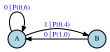

10001001010000001000010101000000010101010001010100


In [110]:
ep = golden_mean_process(0.6)
plot_machine(ep)

N = 10_000
y = simulate(String, ep, N)
println(y[1:50])
@assert !occursin("11", y)  # machine does not allow '11'

In [ ]:
inference = infer_machine(CSSR(), y,
    max_history=2,
    min_count=5,
    alpha = 0.001
)

Inference Result:
  algorithm = CSSR
  sequence_length = 10000
  max_history = 5
  min_count = 5
  alpha = 0.001
  causal_states = 3
  transitions = 5

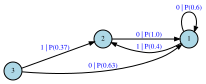

01000010010000010010100000010101000101010100010000


In [112]:
machine = inference.machine
plot_machine(machine)
inferred_y = simulate(String, ep, N)
println(inferred_y[1:50])

In [42]:
# original
println("Original - 1s: ", count(x -> x == '1', y))
println("Original - 0s: ", count(x -> x == '0', y))
# inferred
println("Inferred - 1s: ", count(x -> x == '1', inferred_y))
println("Inferred - 0s: ", count(x -> x == '0', inferred_y))

Original - 1s: 291
Original - 0s: 709
Inferred - 1s: 279
Inferred - 0s: 721


# TODOs
- [ ] Implement `predict` and `filter` function for the machine
- [ ] Implement `transducerCSSR`
- [ ] Test for parity with the Python packages
- [ ] Clean up internals for CSSR algorithm
- [ ] Create user docs
- [ ] Test with 'real' data